In [1]:
import os
import numpy as np
from astropy.table import Table as aT

In [2]:
import util as U

/global/homes/c/chahah/.conda/envs/gqp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
#mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

## load BGS observations

In [4]:
lrg = aT.read('/global/cfs/projectdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.2/LRG_full.dat.fits')

In [5]:
# select only LRG objects with good spectra with successful redshifts within 1 < z < 2 (REVISIT THIS CRITERIA LATER)
is_good = (
    (lrg['COADD_FIBERSTATUS'] == 0) & 
    (lrg['SPECTYPE'] == 'GALAXY') & 
    (lrg['Z_not4clus'] < 1.) & # (lrg['Z_not4clus'] > 1.) & (lrg['Z_not4clus'] < 2.) & 
    (lrg['ZWARN'] == 0))

print('%i out of %i LRG z-success' % (np.sum(is_good), len(is_good)))

2218011 out of 3580917 LRG z-success


In [6]:
lrg = lrg[is_good]

In [7]:
# 1. correct for extinction
flux_g  = lrg['FLUX_G']/lrg['MW_TRANSMISSION_G']
flux_r  = lrg['FLUX_R']/lrg['MW_TRANSMISSION_R']
flux_z  = lrg['FLUX_Z']/lrg['MW_TRANSMISSION_Z']
flux_w1 = lrg['FLUX_W1']/lrg['MW_TRANSMISSION_W1']
flux_w2 = lrg['FLUX_W2']/lrg['MW_TRANSMISSION_W2']

# 2. compile other measurements
redshift = lrg['Z_not4clus']
sig_g  = lrg['FLUX_IVAR_G']**-0.5
sig_r  = lrg['FLUX_IVAR_R']**-0.5
sig_z  = lrg['FLUX_IVAR_Z']**-0.5
sig_w1 = lrg['FLUX_IVAR_W1']**-0.5
sig_w2 = lrg['FLUX_IVAR_W2']**-0.5

# 3. compile together
# flux is in log10 to reduce dynamic range
y_obs = np.array([
    np.log10(flux_g),
    np.log10(flux_r),
    np.log10(flux_z),
    np.log10(flux_w1),
    np.log10(flux_w2),
    sig_g,
    sig_r,
    sig_z,
    sig_w1,
    sig_w2,
    redshift]).T

/tmp/ipykernel_758145/1312660467.py:10: RuntimeWarning: divide by zero encountered in power
  sig_g  = lrg['FLUX_IVAR_G']**-0.5
/tmp/ipykernel_758145/1312660467.py:19: RuntimeWarning: divide by zero encountered in log10
  np.log10(flux_g),
/tmp/ipykernel_758145/1312660467.py:19: RuntimeWarning: invalid value encountered in log10
  np.log10(flux_g),
/tmp/ipykernel_758145/1312660467.py:23: RuntimeWarning: invalid value encountered in log10
  np.log10(flux_w2),


## Load SEDflow test/training data

In [8]:
x_test, y_test = U.load_modelb('test', bands='grzW1W2', infer_redshift=False)
#x_test, y_test = U.load_modelc('test', bands='grzW1W2', infer_redshift=False)

## comparison

In [9]:
lbls = ['$g$', '$r$', '$z$', '$W1$', '$W2$', r'$\sigma_g$', r'$\sigma_r$', r'$\sigma_z$', r'$\sigma_{W1}$', r'$\sigma_{W2}$', 'redshift ($z$)']

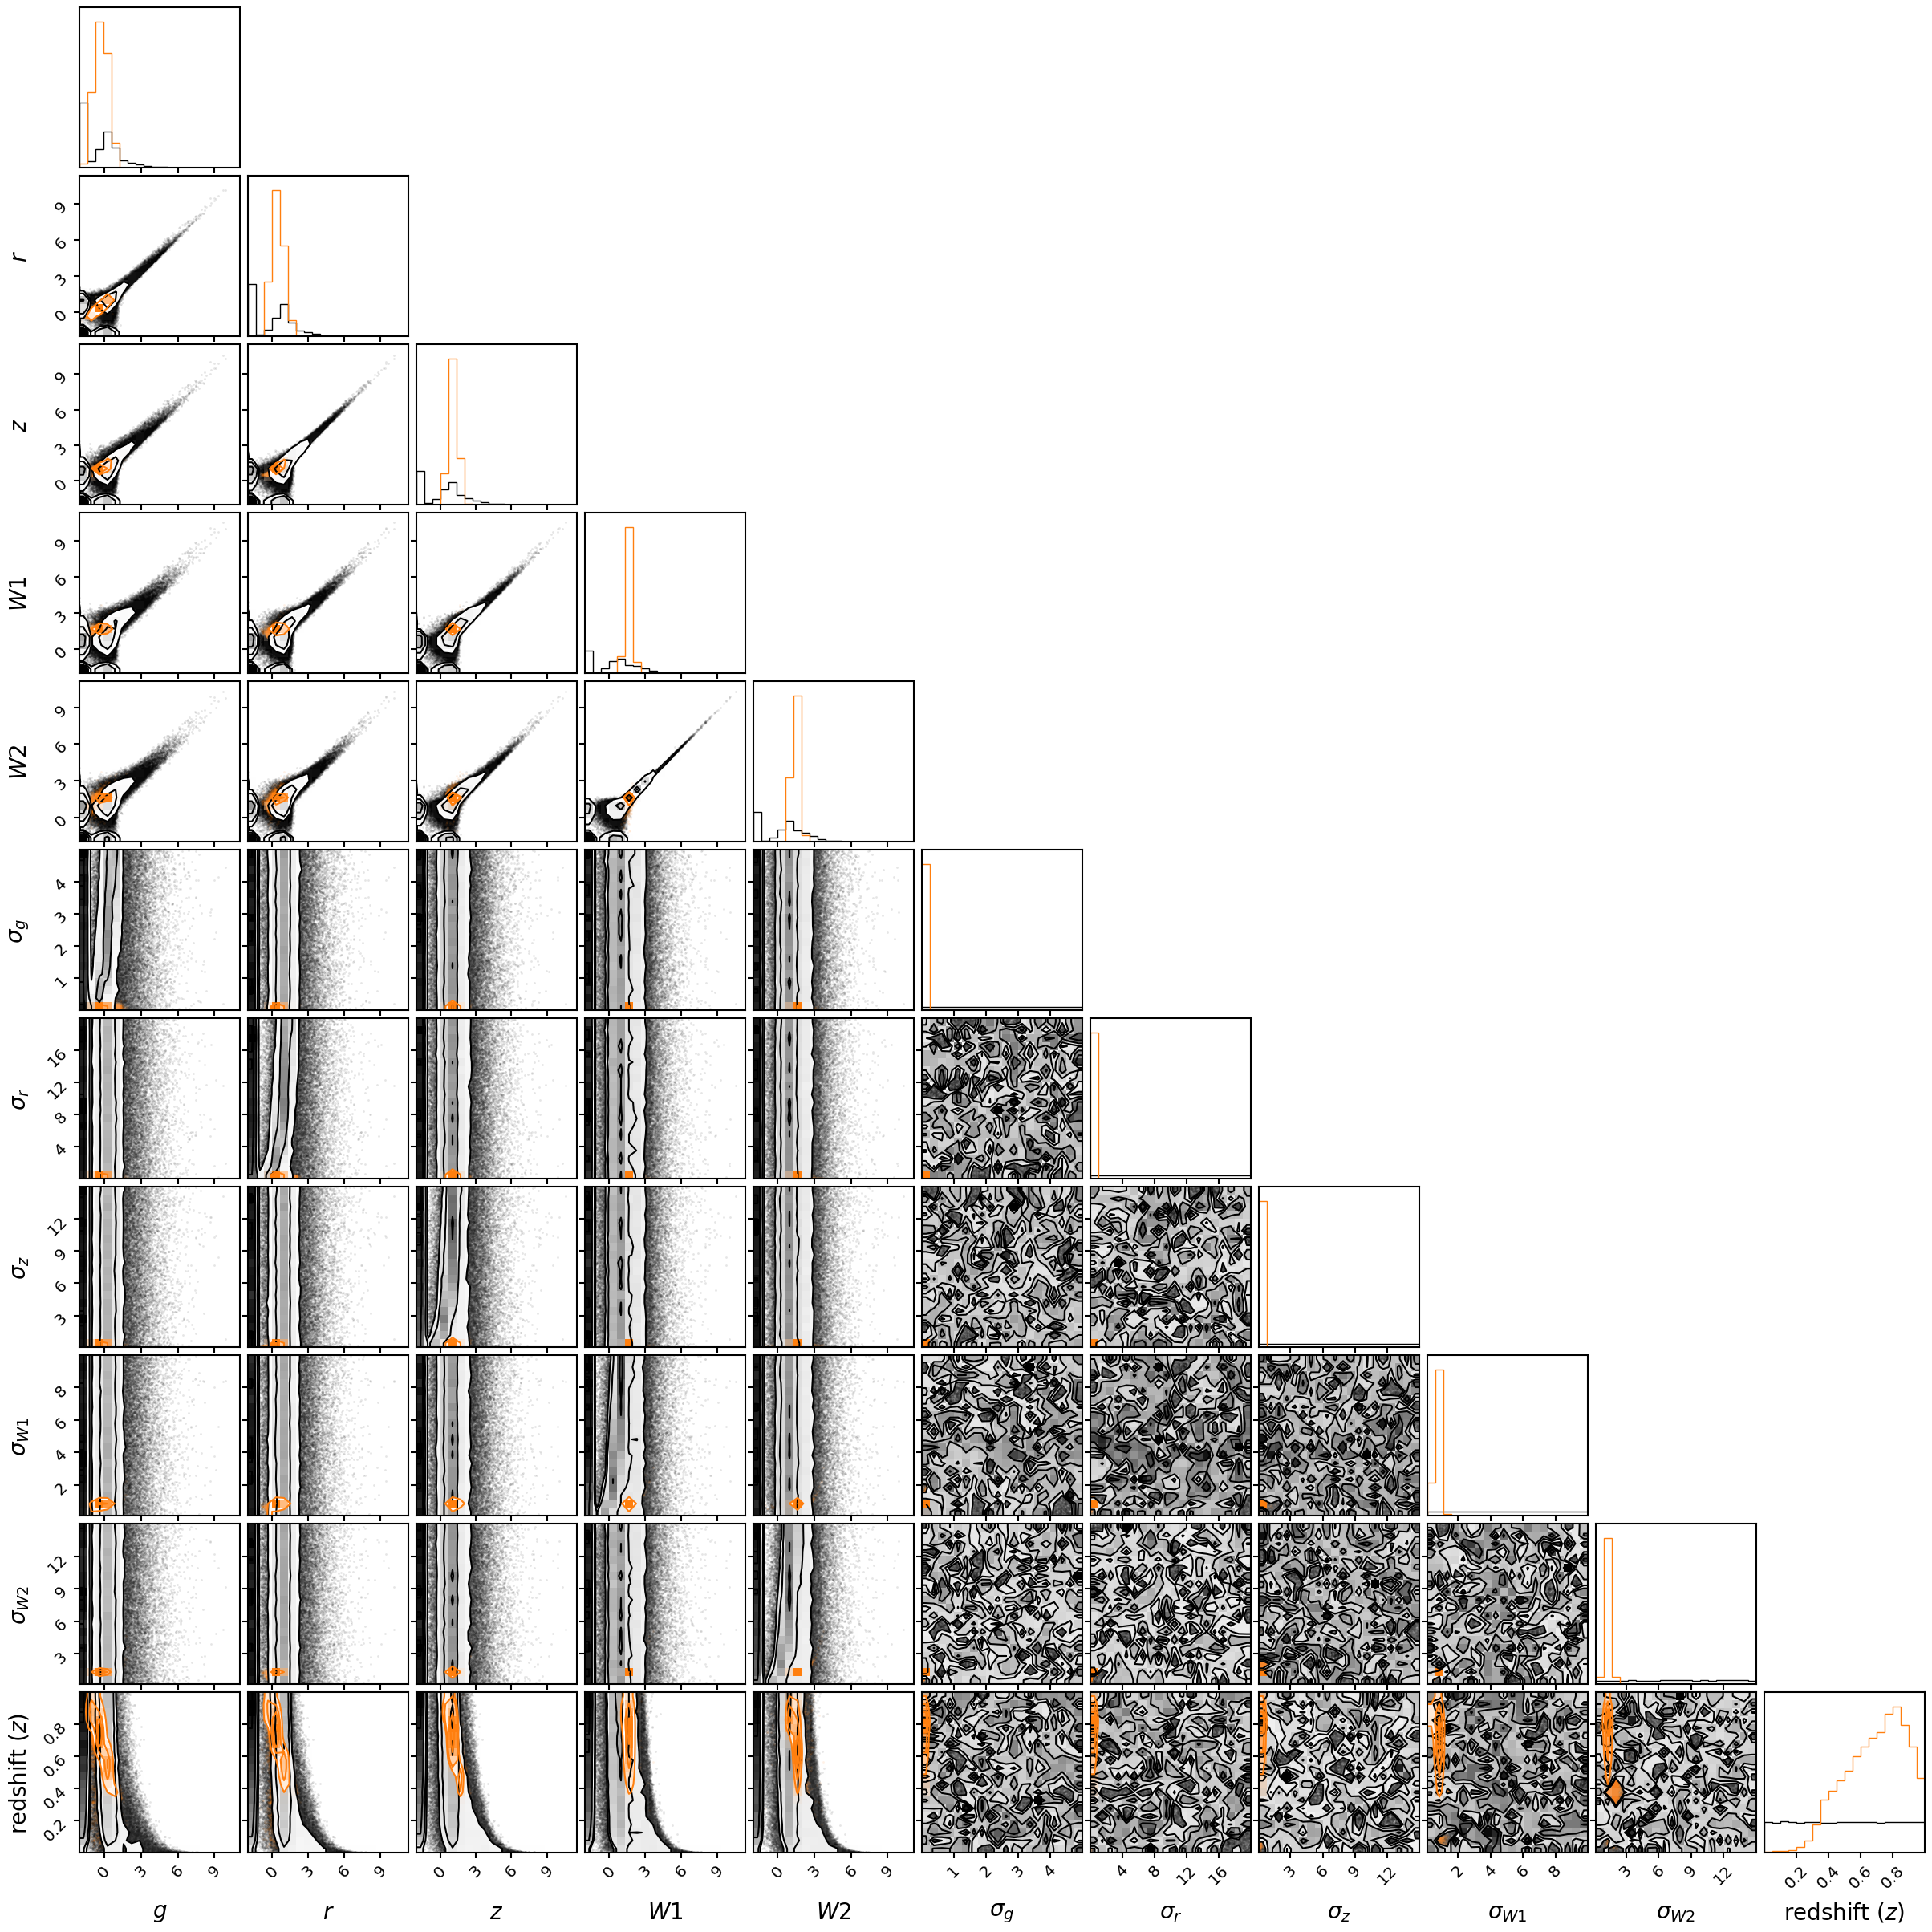

In [10]:
fig = DFM.corner(y_test, range=[(m0, m1) for m0, m1 in zip(np.min(y_test, axis=0), np.max(y_test, axis=0))], 
                 labels=lbls, label_kwargs={'fontsize':20}, hist1d_kwargs={'density=True'})
fig = DFM.corner(y_obs[::10], color='C1', range=[(m0, m1) for m0, m1 in zip(np.min(y_test, axis=0), np.max(y_test, axis=0))], 
           labels=lbls, label_kwargs={'fontsize':20}, hist1d_kwargs={'density=True'},  fig=fig)  

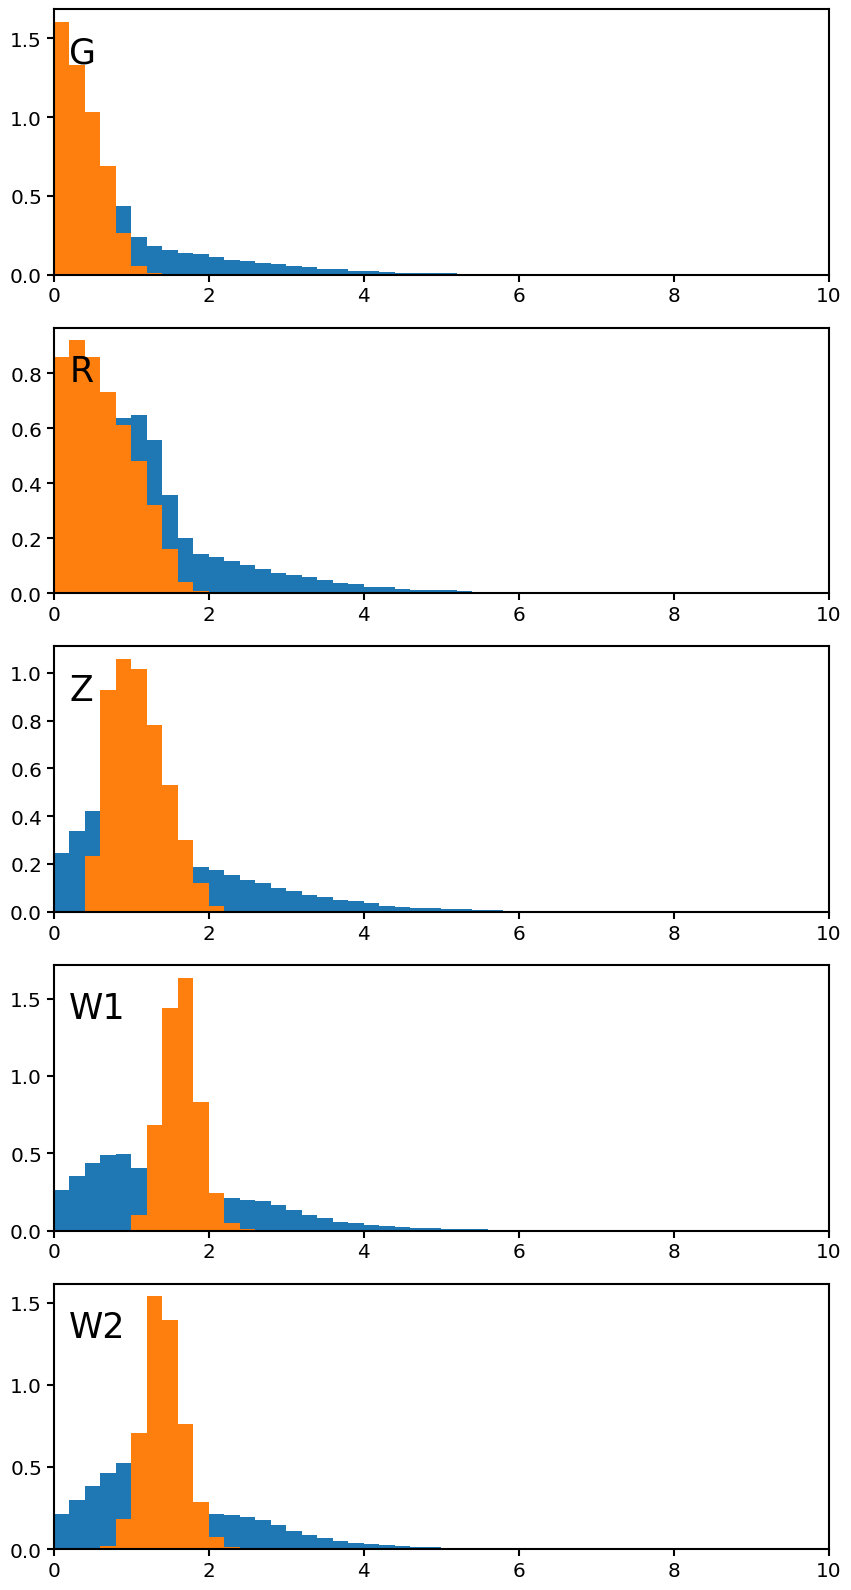

In [11]:
bands = ['G', 'R', 'Z', 'W1', 'W2']

fig = plt.figure(figsize=(10,20))

for i, band in enumerate(bands): 
    sub = fig.add_subplot(5,1,i+1)
    sub.hist(y_test[:,i], range=(0,10), bins=50, density=True)
    sub.hist(y_obs[:,i], range=(0,10), bins=50, density=True)
    
    sub.set_xlim(0, 10)#1e-1, 1e5)
    #sub.set_xscale('log')
    if i == 5: sub.set_xlabel('log(flux [nMgy])', fontsize=25)

    #sub.set_ylim(10**-2.1, 25)
    #sub.set_yscale('log')
    #if i == 0: sub.set_ylabel(r'$\sigma_{\rm flux}$', fontsize=25)
    
    sub.text(0.02, 0.9, band, ha='left', va='top', transform=sub.transAxes, fontsize=25)